In [1]:
import pandas as pd
vapes = pd.read_csv("Canada Vapes Order Data Jan 1, 2021 - Jan 1, 2026.csv")
vapes.head()

,Date,Order #,N. Revenue (formatted),Status,Customer,Customer type,Product(s),Items sold,Coupon(s),Net Sales,Attribution
0,2026-01-01 23:53,785500.0,$68.98,completed,Cody Gallant,new,2× Mixed Berries - CV NOVA 30K,2,NaN,59.98,Organic: Google
1,2026-01-01 23:51,785499.0,$194.96,completed,doug falconer,returning,"4× Red Ultra Salts - 10 mg/ml HIGH, 60ml",4,wlr-ls6-e6g,187.22,Direct
2,2026-01-01 23:48,785498.0,$68.96,completed,Anne-Marie Thivierge,returning,"1× Mint - CV NOVA 30K, 1× Grape Ice - CV NOVA 30K",2,NaN,59.98,Organic: Google
3,2026-01-01 23:44,785497.0,$112.99,completed,Carter Penny,new,1× XMax V3 Pro Dry Herb &amp; Wax Vaporizer - ...,1,NaN,99.99,Referral: Search.brave.com
4,2026-01-01 23:22,785496.0,$153.70,completed,Stephen Brenner,returning,"2× No Flavour - 9 mg/ml MEDIUM, 120ml",2,NaN,147.60,Organic: Google


In [2]:
# Display the number of rows and columns
vapes.shape

(181641, 11)

In [3]:
# Display column names, data types, and missing values
vapes.info()

<class 'pandas.DataFrame'>
RangeIndex: 181641 entries, 0 to 181640
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    181641 non-null  str    
 1   Order #                 181638 non-null  float64
 2   N. Revenue (formatted)  181638 non-null  str    
 3   Status                  181641 non-null  str    
 4   Customer                181641 non-null  str    
 5   Customer type           181641 non-null  str    
 6   Product(s)              113417 non-null  str    
 7   Items sold              181641 non-null  int64  
 8   Coupon(s)               23479 non-null   str    
 9   Net Sales               181641 non-null  float64
 10  Attribution             181641 non-null  str    
dtypes: float64(2), int64(1), str(8)
memory usage: 15.2 MB


In [4]:
# Summary statistics
vapes.describe()

,Order #,Items sold,Net Sales
count,181638.000000,181641.000000,181641.000000
mean,499608.724914,2.967056,100.717472
std,220146.099258,2.330198,75.938369
min,134018.000000,-18.000000,-559.900000
25%,311805.000000,2.000000,58.640000
50%,465001.500000,2.000000,80.980000
75%,728785.750000,4.000000,126.060000
max,785500.000000,92.000000,3967.690000


In [5]:
# convert date to datetime
vapes['Date'] = pd.to_datetime(vapes['Date'])

In [6]:
# check for missing values per column
missing_values = pd.DataFrame({
    'Missing Values': vapes.isna().sum(),
    'Percentage (%)': round((vapes.isna().sum() / len(vapes)) * 100, 2)
})

missing_values

,Missing Values,Percentage (%)
Date,0,0.00
Order #,3,0.00
N. Revenue (formatted),3,0.00
Status,0,0.00
Customer,0,0.00
Customer type,0,0.00
Product(s),68224,37.56
Items sold,0,0.00
Coupon(s),158162,87.07
Net Sales,0,0.00


In [7]:
# check rown where either order number or revenue is missing
vapes[vapes['Order #'].isna() | vapes['N. Revenue (formatted)'].isna()]

,Date,Order #,N. Revenue (formatted),Status,Customer,Customer type,Product(s),Items sold,Coupon(s),Net Sales,Attribution
73822,2024-06-06 13:05:00,NaN,NaN,completed,,returning,NaN,0,NaN,-15.0,Unknown
73834,2024-06-06 12:18:00,NaN,NaN,completed,,returning,NaN,0,NaN,0.0,Unknown
73836,2024-06-06 12:14:00,NaN,NaN,completed,,returning,NaN,0,NaN,0.0,Unknown


In [8]:
# handle missing products (replace)
vapes['Product(s)'] = vapes['Product(s)'].fillna('Unknown')

In [9]:
# handle missing coupons (replace)
vapes['Coupon(s)'] = vapes['Coupon(s)'].fillna('No Coupon')

In [10]:
# drop records with missing order numbers 
vapes = vapes.dropna(subset=['Order #'])

In [11]:
# check for duplicates
vapes['Order #'].duplicated().sum()

np.int64(1305)

In [12]:
# Display rows with duplicate order numbers
duplicates = vapes[vapes['Order #'].duplicated(keep=False)]

duplicates.sort_values('Order #').head(20)

,Date,Order #,N. Revenue (formatted),Status,Customer,Customer type,Product(s),Items sold,Coupon(s),Net Sales,Attribution
175678,2021-04-28 11:59:00,144924.0,$126.09 $0,refunded,Leo Brown,returning,Unknown,1,No Coupon,109.67,Unknown
174703,2021-05-13 10:17:00,144924.0,$126.09 $0,completed,Leo Brown,returning,Unknown,0,No Coupon,-126.09,Unknown
174838,2021-05-11 10:09:00,146124.0,$67.99 $0,completed,,returning,Unknown,0,No Coupon,-67.99,Unknown
174924,2021-05-09 16:23:00,146124.0,$67.99 $0,refunded,,new,Unknown,5,welcome,65.29,Unknown
174903,2021-05-09 23:56:00,146150.0,$68.93 $0,refunded,'-Patricia -MAILLÉ,new,Unknown,5,No Coupon,59.95,Unknown
174877,2021-05-10 12:46:00,146150.0,$68.93 $0,completed,'-Patricia -MAILLÉ,returning,Unknown,0,No Coupon,-68.93,Unknown
142323,2022-07-29 14:27:00,262155.0,$49.13 $0,completed,,returning,Unknown,0,No Coupon,0.00,Unknown
146096,2022-06-14 12:45:00,262155.0,$49.13 $0,refunded,,new,Unknown,1,welcome,46.79,Unknown
145834,2022-06-17 09:27:00,262658.0,$59.86 $49.87,completed,,returning,1× UWELL Caliburn A2 Replacement Pods,0,No Coupon,0.00,Unknown
145989,2022-06-15 15:31:00,262658.0,$59.86 $49.87,completed,,returning,1× UWELL Caliburn A2 Replacement Pods,2,No Coupon,44.28,Unknown


In [13]:
# recheck missing values
missing_values = pd.DataFrame({
    'Missing Count': vapes.isna().sum(),
    'Missing Percentage (%)': round((vapes.isna().mean()) * 100, 2)
})

missing_values

,Missing Count,Missing Percentage (%)
Date,0,0.0
Order #,0,0.0
N. Revenue (formatted),0,0.0
Status,0,0.0
Customer,0,0.0
Customer type,0,0.0
Product(s),0,0.0
Items sold,0,0.0
Coupon(s),0,0.0
Net Sales,0,0.0


In [14]:
# create year, month, quarter for power bi
vapes['Year'] = vapes['Date'].dt.year
vapes['Month'] = vapes['Date'].dt.month_name()
vapes['YearMonth'] = vapes['Date'].dt.to_period('M').astype(str)
vapes['Quarter'] = vapes['Date'].dt.quarter

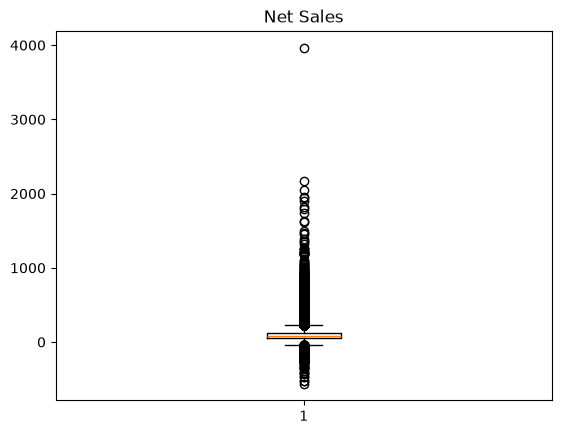

In [15]:
# check outliers
import matplotlib.pyplot as plt

plt.boxplot(vapes['Net Sales'])
plt.title("Net Sales")
plt.show()

In [16]:
# check summary stats
vapes.describe()

,Date,Order #,Items sold,Net Sales,Year,Quarter
count,181638,181638.000000,181638.000000,181638.000000,181638.000000,181638.000000
mean,2023-11-13 07:20:36.577478,499608.724914,2.967105,100.719219,2023.358130,2.532658
min,2021-01-03 15:00:00,134018.000000,-18.000000,-559.900000,2021.000000,1.000000
25%,2022-10-01 11:35:45,311805.000000,2.000000,58.640000,2022.000000,2.000000
50%,2024-01-22 20:49:00,465001.500000,2.000000,80.980000,2024.000000,3.000000
75%,2025-01-20 16:00:45,728785.750000,4.000000,126.060000,2025.000000,4.000000
max,2026-01-01 23:53:00,785500.000000,92.000000,3967.690000,2026.000000,4.000000
std,NaN,220146.099258,2.330186,75.937775,1.357763,1.114995


In [19]:
# save cleaned csv 
vapes.to_csv(
    "Canada_Vapes_Order_Dataset_Cleaned.csv",
    index=False
)